# Horse Races Analysis
Sravana Nuti

# Objective
The objectives of this notebook are:
1.   Perform Exploratory Data Analysis
2.   Build Predictive Model to predict for a horse to finish the race
3.   Draw Insights from Data and Model

# Given
*   The data set provided are two ***.CSV*** files containing data about horses and the races.
* Races Dataframe: Contains data about indivudal *races* held
* Runs Dataframe: Contains information about the *horses* that participated






# Summary
This notebook begins by performing exploratory data analysis. It begins by importing the data from a CSV files and utilizes Pandas library to convert the data to a dataframe. Next, it performs various data clearning, wrangling, and pre-processing methods to create a pipeline to feed to the machine learning models. In addition, there are several plots to help visualize the data. Next, the pipeline is fed into a Linear Regression model to predict the time it takes for a horse to finish a race. It refines the model using Recursive Feature Elimination. Finally, using this analysis various insights can be gained.

# Preliminary

## Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
import plotly.figure_factory as ff
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


## Loading Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
runs_df = pd.read_csv('/content/drive/MyDrive/Semester 2/WAF/runs.csv')
races_df = pd.read_csv('/content/drive/MyDrive/Semester 2/WAF/races.csv')

# Pre-Processing Data Structures

In this section, we will first explore the data structure for our two dataframes: **``` races_df ```** and **``` runs_df ```**. First we analyze the shape of each structure, the total number of rows (instances) and columns (features) available. We will take a look at the different data types available and any **missing/null** values.



## ```runs_df```



### Viewing Data Structure

In [ ]:
runs_df.shape

(79447, 37)

In [ ]:
runs_df.head()

,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_country,horse_type,horse_rating,...,time2,time3,time4,time5,time6,finish_time,win_odds,place_odds,trainer_id,jockey_id
0,0,1,3917,10,0.0,8.00,3,AUS,Gelding,60,...,21.59,23.86,24.62,NaN,NaN,83.92,9.7,3.7,118,2
1,0,2,2157,8,0.0,5.75,3,NZ,Gelding,60,...,21.99,23.30,23.70,NaN,NaN,83.56,16.0,4.9,164,57
2,0,3,858,7,0.0,4.75,3,NZ,Gelding,60,...,21.59,23.90,24.22,NaN,NaN,83.40,3.5,1.5,137,18
3,0,4,1853,9,0.0,6.25,3,SAF,Gelding,60,...,21.83,23.70,24.00,NaN,NaN,83.62,39.0,11.0,80,59
4,0,5,2796,6,0.0,3.75,3,GB,Gelding,60,...,21.75,23.22,23.50,NaN,NaN,83.24,50.0,14.0,9,154


It appears that there are a total of 79,447 **instances** and 37 **features** in **```runs_df ```**


In [ ]:
runs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79447 entries, 0 to 79446
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   race_id          79447 non-null  int64  
 1   horse_no         79447 non-null  int64  
 2   horse_id         79447 non-null  int64  
 3   result           79447 non-null  int64  
 4   won              79447 non-null  float64
 5   lengths_behind   79447 non-null  float64
 6   horse_age        79447 non-null  int64  
 7   horse_country    79445 non-null  object 
 8   horse_type       79445 non-null  object 
 9   horse_rating     79447 non-null  int64  
 10  horse_gear       79447 non-null  object 
 11  declared_weight  79447 non-null  float64
 12  actual_weight    79447 non-null  int64  
 13  draw             79447 non-null  int64  
 14  position_sec1    79447 non-null  int64  
 15  position_sec2    79447 non-null  int64  
 16  position_sec3    79447 non-null  int64  
 17  position_sec

We can see that most of the features are numerical values. However **horse_country**, **horse_type**, **horse_gear** are categorical variables. It is necessary that we encode these features before constructing ML data pipeline since ML models cannot handle categorical values.




### Handling Missing Values

In [ ]:
runs_df.isna().sum()

race_id                0
horse_no               0
horse_id               0
result                 0
won                    0
lengths_behind         0
horse_age              0
horse_country          2
horse_type             2
horse_rating           0
horse_gear             0
declared_weight        0
actual_weight          0
draw                   0
position_sec1          0
position_sec2          0
position_sec3          0
position_sec4      33221
position_sec5      69368
position_sec6      78151
behind_sec1            0
behind_sec2            0
behind_sec3            0
behind_sec4        33221
behind_sec5        69368
behind_sec6        78151
time1                  0
time2                  0
time3                  0
time4              33221
time5              69368
time6              78151
finish_time            0
win_odds               0
place_odds          3735
trainer_id             0
jockey_id              0
dtype: int64

From this list, we can see that features **horse_country**, **horse_type**, **position_sec4**, **position_sec5**, **position_sec6**, **behind_sec4**, **behind_sec5**, **behind_sec6**, **time4**, **time5**, **time6**, and **place_odds** have missing values. These need to be dealt with.  

---

It is ineresting to note that the missing values are somewhat consistent. There is a large number of missing values corresponding to section 4,5, and 6. It seems that for these areas, the data was not recorded properly.



To deal with missing values **horse_country** and **horse_type**, we are going to drop those rows. There 2 missing values in each category, and hence can be dropped. They make up a very small number of the dataset, and we will not lose too much information.

In [ ]:
runs_temp_df_1 = runs_df.dropna(subset=['horse_country','horse_type'])

In [ ]:
runs_temp_df_1.head()

,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_country,horse_type,horse_rating,...,time2,time3,time4,time5,time6,finish_time,win_odds,place_odds,trainer_id,jockey_id
0,0,1,3917,10,0.0,8.00,3,AUS,Gelding,60,...,21.59,23.86,24.62,NaN,NaN,83.92,9.7,3.7,118,2
1,0,2,2157,8,0.0,5.75,3,NZ,Gelding,60,...,21.99,23.30,23.70,NaN,NaN,83.56,16.0,4.9,164,57
2,0,3,858,7,0.0,4.75,3,NZ,Gelding,60,...,21.59,23.90,24.22,NaN,NaN,83.40,3.5,1.5,137,18
3,0,4,1853,9,0.0,6.25,3,SAF,Gelding,60,...,21.83,23.70,24.00,NaN,NaN,83.62,39.0,11.0,80,59
4,0,5,2796,6,0.0,3.75,3,GB,Gelding,60,...,21.75,23.22,23.50,NaN,NaN,83.24,50.0,14.0,9,154


Next, the **place_odds** column has 4.7% missing values, which is a sizable amount. Dropping these valuse would result in loss of information that can used in our machine learning models. Hence, we will using KNN Imputer to fill in the missing data.

Similarly, **position_sec4, position_sec5, position_sec6, behind_sec4, behind_sec5, behind_sec6, time4, time5, time6** each have 41%-98% of the values in their respective columns missing.

This presents as us with a dilema regarding how to proceed further. We can drop these columns since a significant portion of the vlaues are missing. However, this can introduce bias and cause of information, since we are removing 9 features. Another alternative is to impute these values using KNN.

We will try both options. We are going to experiment to see which data processing method provides better metrics in our machine learning model and select that data cleaning method.



Option 1: KNN Imputation

In [ ]:
from sklearn.impute import KNNImputer

#numerical_float_columns = runs_temp_df_1.select_dtypes(include=[np.number,'float']).columns.to_list()
#selected_data = runs_temp_df_1[numerical_float_columns]
#imputer = KNNImputer(n_neighbors=2)
#runs_imputed_data = imputer.fit_transform(selected_data)
#imputed_df = pd.DataFrame(runs_imputed_data, columns=numerical_float_columns)

In [ ]:
#runs_imputed_cleaned_df.isna().sum()

This option will **not** be pursured. The large dataset, increased variablity, and numerous missing values are preventing the algorithm from converging. Even with reducing the number of neighbors, the algorithm is not converging. Due to limited computation capacity, this option of imputing the missing values using KNN will be abandoned.

Option 2: Dropping Columns with Null Values

Hence, we will replace our missing values by dropping the columns.

In [ ]:
runs_temp_df_3 = runs_temp_df_1.dropna(subset=['place_odds'])
runs_dropped_cleaned_df = runs_temp_df_3.dropna(axis=1)

In [ ]:
runs_dropped_cleaned_df.isna().sum()

race_id            0
horse_no           0
horse_id           0
result             0
won                0
lengths_behind     0
horse_age          0
horse_country      0
horse_type         0
horse_rating       0
horse_gear         0
declared_weight    0
actual_weight      0
draw               0
position_sec1      0
position_sec2      0
position_sec3      0
behind_sec1        0
behind_sec2        0
behind_sec3        0
time1              0
time2              0
time3              0
finish_time        0
win_odds           0
place_odds         0
trainer_id         0
jockey_id          0
dtype: int64

In [ ]:
runs_dropped_cleaned_df.shape

(75710, 28)

## ```races_df```



### Viewing Data Structure

In [ ]:
races_df.shape

(6349, 37)

In [ ]:
races_df.head()

,race_id,date,venue,race_no,config,surface,distance,going,horse_ratings,prize,...,place_combination3,place_combination4,place_dividend1,place_dividend2,place_dividend3,place_dividend4,win_combination1,win_dividend1,win_combination2,win_dividend2
0,0,1997-06-02,ST,1,A,0,1400,GOOD TO FIRM,40-15,485000.0,...,6.0,NaN,36.5,25.5,18.0,NaN,8,121.0,NaN,NaN
1,1,1997-06-02,ST,2,A,0,1200,GOOD TO FIRM,40-15,485000.0,...,4.0,NaN,12.5,47.0,33.5,NaN,5,23.5,NaN,NaN
2,2,1997-06-02,ST,3,A,0,1400,GOOD TO FIRM,60-40,625000.0,...,13.0,NaN,23.0,23.0,59.5,NaN,11,70.0,NaN,NaN
3,3,1997-06-02,ST,4,A,0,1200,GOOD TO FIRM,120-95,1750000.0,...,10.0,NaN,14.0,24.5,16.0,NaN,5,52.0,NaN,NaN
4,4,1997-06-02,ST,5,A,0,1600,GOOD TO FIRM,60-40,625000.0,...,1.0,NaN,15.5,28.0,17.5,NaN,2,36.5,NaN,NaN


It appears that there are a total of 6349 **instances** and 37 **features** in **```races_df ```**. Compared to **```runs_df ```**, this dataframe has the same number of features, but fewer instancse.

In [ ]:
print(type(races_df['date'][0]))

<class 'str'>


The date column is a string object type. This cannot be used in our Machine Learning Model. Hence we will first convert it to a date time object. However, we cannot use the datetime object in the ML algorithms as well. Si, we will separate it out into year, month, and day columns. This way we can retain the original date information and still use them in our machine learning model.

In [ ]:
races_df['date'] = pd.to_datetime(races_df['date'])
races_df['year'] = races_df['date'].dt.year
races_df['month'] = races_df['date'].dt.month
races_df['day'] = races_df['date'].dt.day

races_df.drop(columns=['date'], inplace=True)
races_df.head()

,race_id,venue,race_no,config,surface,distance,going,horse_ratings,prize,race_class,...,place_dividend2,place_dividend3,place_dividend4,win_combination1,win_dividend1,win_combination2,win_dividend2,year,month,day
0,0,ST,1,A,0,1400,GOOD TO FIRM,40-15,485000.0,5,...,25.5,18.0,NaN,8,121.0,NaN,NaN,1997,6,2
1,1,ST,2,A,0,1200,GOOD TO FIRM,40-15,485000.0,5,...,47.0,33.5,NaN,5,23.5,NaN,NaN,1997,6,2
2,2,ST,3,A,0,1400,GOOD TO FIRM,60-40,625000.0,4,...,23.0,59.5,NaN,11,70.0,NaN,NaN,1997,6,2
3,3,ST,4,A,0,1200,GOOD TO FIRM,120-95,1750000.0,1,...,24.5,16.0,NaN,5,52.0,NaN,NaN,1997,6,2
4,4,ST,5,A,0,1600,GOOD TO FIRM,60-40,625000.0,4,...,28.0,17.5,NaN,2,36.5,NaN,NaN,1997,6,2


In [ ]:
races_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6349 entries, 0 to 6348
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   race_id             6349 non-null   int64  
 1   venue               6349 non-null   object 
 2   race_no             6349 non-null   int64  
 3   config              6349 non-null   object 
 4   surface             6349 non-null   int64  
 5   distance            6349 non-null   int64  
 6   going               6349 non-null   object 
 7   horse_ratings       6349 non-null   object 
 8   prize               5887 non-null   float64
 9   race_class          6349 non-null   int64  
 10  sec_time1           6349 non-null   float64
 11  sec_time2           6349 non-null   float64
 12  sec_time3           6349 non-null   float64
 13  sec_time4           3634 non-null   float64
 14  sec_time5           821 non-null    float64
 15  sec_time6           115 non-null    float64
 16  sec_ti

We can see that most of the features are numerical values. However **date**,**venue**, **config**, **going**, **horse_ratings** are categorical variables that need to be encoded


### Handling Missing Values

In [ ]:
races_df.isna().sum()

race_id                  0
venue                    0
race_no                  0
config                   0
surface                  0
distance                 0
going                    0
horse_ratings            0
prize                  462
race_class               0
sec_time1                0
sec_time2                0
sec_time3                0
sec_time4             2715
sec_time5             5528
sec_time6             6234
sec_time7             6349
time1                    0
time2                    0
time3                    0
time4                 2715
time5                 5528
time6                 6234
time7                 6349
place_combination1       0
place_combination2       0
place_combination3      25
place_combination4    6326
place_dividend1          0
place_dividend2          0
place_dividend3         25
place_dividend4       6326
win_combination1         0
win_dividend1            0
win_combination2      6337
win_dividend2         6337
year                     0
m

From this list, we can see that features **prize**, **sec_time4**, **sec_time5**, **sec_time6**, **sec_time7**, **time4**, **time5**, **time6**, **time7**, **place_combination3**, **place_combination4**, **place_dividend3**, **place_dividend4**, **win_combination2**, and **win_dividend2** have missing values. These need to be dealt with.

**sec_time7**, **time7** have 100% missing values. They will not provide any information to us. Hence, we will drop these columns.

In [ ]:
races_df.drop(columns=['time7','sec_time7'], inplace=True)

**win_combination2** is the horse that ties with the first horse. This is why it makes sense that there are so many rows that are empty. Only some of the rows had winning combinations. Hence, we are going to change this column into a flag. If there is a horse that tied first place, it is True, else it is False. Its correponding column **win_dividend2** is the prize money for the tied horses. Hence we will keep the amount that was won, and replace the missing values with $0.

In [ ]:
races_df['win_combination2'] = races_df['win_combination2'].fillna(0)
races_df.loc[races_df['win_combination2'] != 0, 'win_combination2'] = 1

# win_dividend2
races_df['win_dividend2'] = races_df['win_dividend2'].fillna(0)

**place_combination3,place_combination4** are the horses that came in thrid and fourth place. We can predict who came third and fourth, but these are objective values that must be recorded from the race. **place_combination4** column has 99.6% of the values are missing. Hence, we can drop the entire column. Similarly, its corresponding column **place_dividend4** can be dropped as well. It does not make sense to have the winning prize for a column that does not exist. **place_combination3** has .3% missing values. Overall, this is a insignificant number. So the rows with missing values can be dropped.

In [ ]:
races_df.drop(columns=['place_combination4','place_dividend4'], inplace=True)

In [ ]:
races_df.dropna(subset=['place_combination3'], inplace=True)

From the data, we can see that **prize, sec_time4, sec_time5, sec_time6,  time4, time5, time6** have significant portions of the dataset. More importantly, these are continous values that can be imputed. These null values will be handles by KNN imputation. Compared to the ```runs_df```, ```races_df``` is a significantly smaller dataset. Dropping columns, or rows would would cause information loss and introduce bias to the dataset.  

In [ ]:
races_df.shape

(6324, 35)

KNN handles only numeric values. There are three columns with categorical columns. These will be encoded to LabelEncoder.

In [ ]:
categorical = ['venue', 'config', 'going', 'horse_ratings']
label_encoder = LabelEncoder()

for column in categorical:
    races_df[column] = label_encoder.fit_transform(races_df[column])


In [ ]:
imputer = KNNImputer(n_neighbors=3)
races_imputed_data = imputer.fit_transform(races_df)
imputed_df = pd.DataFrame(races_imputed_data, columns=races_df.columns)

In [ ]:
imputed_df.isna().sum()

race_id               0
venue                 0
race_no               0
config                0
surface               0
distance              0
going                 0
horse_ratings         0
prize                 0
race_class            0
sec_time1             0
sec_time2             0
sec_time3             0
sec_time4             0
sec_time5             0
sec_time6             0
time1                 0
time2                 0
time3                 0
time4                 0
time5                 0
time6                 0
place_combination1    0
place_combination2    0
place_combination3    0
place_dividend1       0
place_dividend2       0
place_dividend3       0
win_combination1      0
win_dividend1         0
win_combination2      0
win_dividend2         0
year                  0
month                 0
day                   0
dtype: int64

In [ ]:
pd.set_option('display.max_columns', None)
imputed_df.head(20)

,race_id,venue,race_no,config,surface,distance,going,horse_ratings,prize,race_class,sec_time1,sec_time2,sec_time3,sec_time4,sec_time5,sec_time6,time1,time2,time3,time4,time5,time6,place_combination1,place_combination2,place_combination3,place_dividend1,place_dividend2,place_dividend3,win_combination1,win_dividend1,win_combination2,win_dividend2,year,month,day
0,0.0,1.0,1.0,0.0,0.0,1400.0,2.0,13.0,485000.0,5.0,13.53,21.59,23.94,23.580000,24.156667,24.243333,13.53,35.12,59.06,82.640000,110.456667,138.600000,8.0,11.0,6.0,36.5,25.5,18.0,8.0,121.0,0.0,0.0,1997.0,6.0,2.0
1,1.0,1.0,2.0,0.0,0.0,1200.0,2.0,13.0,485000.0,5.0,24.05,22.64,23.70,23.673333,24.156667,24.243333,24.05,46.69,70.39,83.186667,110.456667,138.600000,5.0,13.0,4.0,12.5,47.0,33.5,5.0,23.5,0.0,0.0,1997.0,6.0,2.0
2,2.0,1.0,3.0,0.0,0.0,1400.0,2.0,16.0,625000.0,4.0,13.77,22.22,24.88,22.820000,24.023333,24.296667,13.77,35.99,60.87,83.690000,110.110000,139.126667,11.0,1.0,13.0,23.0,23.0,59.5,11.0,70.0,0.0,0.0,1997.0,6.0,2.0
3,3.0,1.0,4.0,0.0,0.0,1200.0,2.0,10.0,1750000.0,1.0,24.33,22.47,22.09,23.433333,23.700000,24.243333,24.33,46.80,68.89,82.773333,109.303333,138.600000,5.0,3.0,10.0,14.0,24.5,16.0,5.0,52.0,0.0,0.0,1997.0,6.0,2.0
4,4.0,1.0,5.0,0.0,0.0,1600.0,2.0,16.0,625000.0,4.0,25.45,23.52,23.31,23.560000,24.093333,24.296667,25.45,48.97,72.28,95.840000,110.450000,139.126667,2.0,10.0,1.0,15.5,28.0,17.5,2.0,36.5,0.0,0.0,1997.0,6.0,2.0
5,5.0,1.0,6.0,0.0,0.0,1200.0,2.0,16.0,625000.0,4.0,23.47,22.48,23.25,23.033333,24.023333,24.296667,23.47,45.95,69.20,82.923333,110.110000,139.126667,9.0,14.0,8.0,16.5,408.0,70.0,9.0,61.0,0.0,0.0,1997.0,6.0,2.0
6,6.0,1.0,7.0,0.0,0.0,1400.0,2.0,2.0,1150000.0,2.0,13.75,21.61,22.81,23.340000,23.303333,24.243333,13.75,35.36,58.17,81.510000,109.600000,138.600000,5.0,7.0,6.0,41.5,21.5,79.0,5.0,160.5,0.0,0.0,1997.0,6.0,2.0
7,7.0,1.0,8.0,0.0,0.0,1000.0,2.0,2.0,1150000.0,2.0,13.55,20.56,22.44,23.546667,23.303333,24.243333,13.55,34.11,56.55,82.193333,109.600000,138.600000,13.0,3.0,8.0,23.5,44.5,18.0,13.0,70.5,0.0,0.0,1997.0,6.0,2.0
8,8.0,1.0,9.0,0.0,0.0,1400.0,2.0,21.0,850000.0,3.0,13.31,22.20,23.92,23.160000,23.366667,24.243333,13.31,35.51,59.43,82.590000,110.173333,138.600000,7.0,5.0,2.0,12.5,16.5,33.5,7.0,24.0,0.0,0.0,1997.0,6.0,2.0
9,9.0,1.0,10.0,0.0,0.0,1200.0,2.0,21.0,850000.0,3.0,24.08,23.45,22.66,22.823333,23.416667,24.243333,24.08,47.53,70.19,82.516667,110.506667,138.600000,1.0,13.0,6.0,49.5,45.5,14.0,1.0,203.0,0.0,0.0,1997.0,6.0,2.0


# Exploratory Data Analysis

## Statistical Analysis

In [ ]:
# Races Dataframe
numerical_races_column = ['distance',
       'prize', 'sec_time1', 'sec_time2',
       'sec_time3', 'sec_time4', 'sec_time5', 'sec_time6', 'time1', 'time2',
       'time3', 'time4', 'time5', 'time6',
       'place_dividend1', 'place_dividend2', 'place_dividend3',
       'win_dividend1',
       'year', 'month', 'day']
cat_races_column = ['venue', 'config', 'surface', 'distance', 'going', 'horse_ratings',
                    'race_class', 'place_combination1', 'place_combination2', 'place_combination3',
                    'win_combination1', 'win_combination2']

In [ ]:
non_cat_races_df = imputed_df[numerical_races_column]
non_cat_races_df.describe()

,distance,prize,sec_time1,sec_time2,sec_time3,sec_time4,sec_time5,sec_time6,time1,time2,time3,time4,time5,time6,place_dividend1,place_dividend2,place_dividend3,win_dividend1,year,month,day
count,6324.000000,6.324000e+03,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000,6324.00000,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000,6324.000000
mean,1419.283681,1.115056e+06,20.710806,22.827060,23.832603,23.669326,23.839629,24.057667,20.710806,43.537867,67.37047,87.976457,110.148240,138.490132,27.817821,32.809266,38.969292,96.319892,2000.995731,6.882669,15.955408
std,281.105636,1.686949e+06,5.878256,1.041963,0.867950,0.696128,0.438413,0.298328,5.878256,6.653322,6.97251,7.409810,2.513577,1.841802,25.209697,30.289157,37.015938,131.413622,2.422706,3.555461,8.836214
min,1000.000000,4.850000e+05,12.390000,20.060000,21.200000,21.400000,21.810000,21.770000,12.390000,33.110000,55.16000,80.430000,105.830000,132.840000,10.100000,10.100000,10.100000,11.500000,1997.000000,1.000000,1.000000
25%,1200.000000,6.533333e+05,13.690000,22.140000,23.220000,23.230000,23.566667,23.900000,13.690000,35.950000,59.83000,82.630000,109.120000,137.456667,15.000000,17.000000,18.500000,34.500000,1999.000000,3.000000,8.000000
50%,1400.000000,8.283333e+05,23.720000,22.800000,23.725000,23.560000,23.816667,24.076667,23.720000,46.420000,69.73000,83.360000,109.700000,138.250000,20.000000,24.000000,27.500000,58.500000,2001.000000,7.000000,16.000000
75%,1650.000000,1.060000e+06,24.700000,23.450000,24.380000,23.983333,24.093333,24.243333,24.700000,48.070000,72.10250,95.522500,110.353333,138.793333,31.000000,36.500000,44.000000,106.000000,2003.000000,10.000000,24.000000
max,2400.000000,2.500000e+07,30.030000,27.410000,27.580000,28.920000,26.500000,25.920000,30.030000,56.220000,81.29000,107.810000,134.310000,158.490000,410.500000,627.000000,420.500000,2687.500000,2005.000000,12.000000,31.000000


In [ ]:
plt.figure(figsize=(8, 8))
corr_mat = imputed_df[numerical_races_column].corr()
# Create the heatmap
fig = ff.create_annotated_heatmap(
    z=corr_mat.values,
    x=corr_mat.columns.tolist(),
    y=corr_mat.index.tolist(),
    colorscale='RdBu',
    annotation_text=corr_mat.round(2).values,
    showscale=True,
    reversescale=True
)

# Update layout
fig.update_layout(title_text='Races_df Correlation Heatmap', title_x=0.5)
fig.show()

<Figure size 800x800 with 0 Axes>

From the correlation heatmap, we can see that there is high multi-colinearity that exists in this dataframe. There are numerous features that are correlated. This could impact our modeling tasks. This might be due to redundant information present in the dataframe. When preparing the data arrays for the machine learning models, we must consider this and do feature engineering to remove this multi-colinearity.

In [ ]:
# Runs Dataframe
numerical_runs_column = ['declared_weight', 'actual_weight','lengths_behind',
       'position_sec1', 'position_sec2', 'position_sec3', 'behind_sec1',
       'behind_sec2', 'behind_sec3', 'time1', 'time2', 'time3', 'finish_time',
       'win_odds', 'place_odds']
cat_runs_column = ['horse_id', 'result', 'won',
       'horse_country', 'horse_type', 'horse_rating',
       'horse_gear', 'draw']

In [ ]:
non_cat_runs_df = runs_dropped_cleaned_df[numerical_runs_column]
non_cat_runs_df.describe()

,declared_weight,actual_weight,lengths_behind,position_sec1,position_sec2,position_sec3,behind_sec1,behind_sec2,behind_sec3,time1,time2,time3,finish_time,win_odds,place_odds
count,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000,75710.000000
mean,1104.519167,122.720473,6.158935,6.852371,6.849452,6.846176,3.380611,4.084123,4.518402,21.122606,22.928399,23.869851,85.372390,28.824421,7.423203
std,62.349880,6.309469,34.241912,3.735625,3.734410,3.733421,4.353951,2.690893,16.538929,6.976954,3.680240,3.652099,18.549041,30.119082,8.823533
min,693.000000,103.000000,-0.500000,1.000000,1.000000,1.000000,0.150000,0.150000,0.000000,12.390000,19.990000,21.000000,55.160000,1.000000,1.000000
25%,1062.000000,118.000000,1.750000,4.000000,4.000000,4.000000,1.500000,1.750000,1.750000,14.120000,22.300000,23.240000,70.600000,7.700000,2.400000
50%,1101.000000,123.000000,4.000000,7.000000,7.000000,7.000000,3.000000,3.750000,3.750000,24.180000,22.880000,23.770000,83.390000,15.000000,4.100000
75%,1145.000000,128.000000,6.750000,10.000000,10.000000,10.000000,5.000000,5.750000,5.750000,25.360000,23.510000,24.420000,100.790000,38.000000,8.600000
max,1369.000000,133.000000,999.000000,14.000000,14.000000,14.000000,999.000000,60.250000,999.000000,999.000000,999.000000,999.000000,163.580000,99.000000,101.000000


In [ ]:
plt.figure(figsize=(8, 8))
corr_mat = runs_dropped_cleaned_df[numerical_runs_column].corr()
# Create the heatmap
fig = ff.create_annotated_heatmap(
    z=corr_mat.values,
    x=corr_mat.columns.tolist(),
    y=corr_mat.index.tolist(),
    colorscale='RdBu',
    annotation_text=corr_mat.round(2).values,
    showscale=True,
    reversescale=True
)

# Update layout
fig.update_layout(title_text='Correlation Heatmap', title_x=0.5)
fig.show()

<Figure size 800x800 with 0 Axes>

From the correlation heatmap, we can see that there is high multi-colinearity that exists in this dataframe. There are numerous features that are correlated. This could impact our modeling tasks. This might be due to redundant information present in the dataframe. When preparing the data arrays for the machine learning models, we must consider this and do feature engineering to remove this multi-colinearity.

## Basic Categorical Data Visualization

In [ ]:
cat_races_df= imputed_df[cat_races_column]

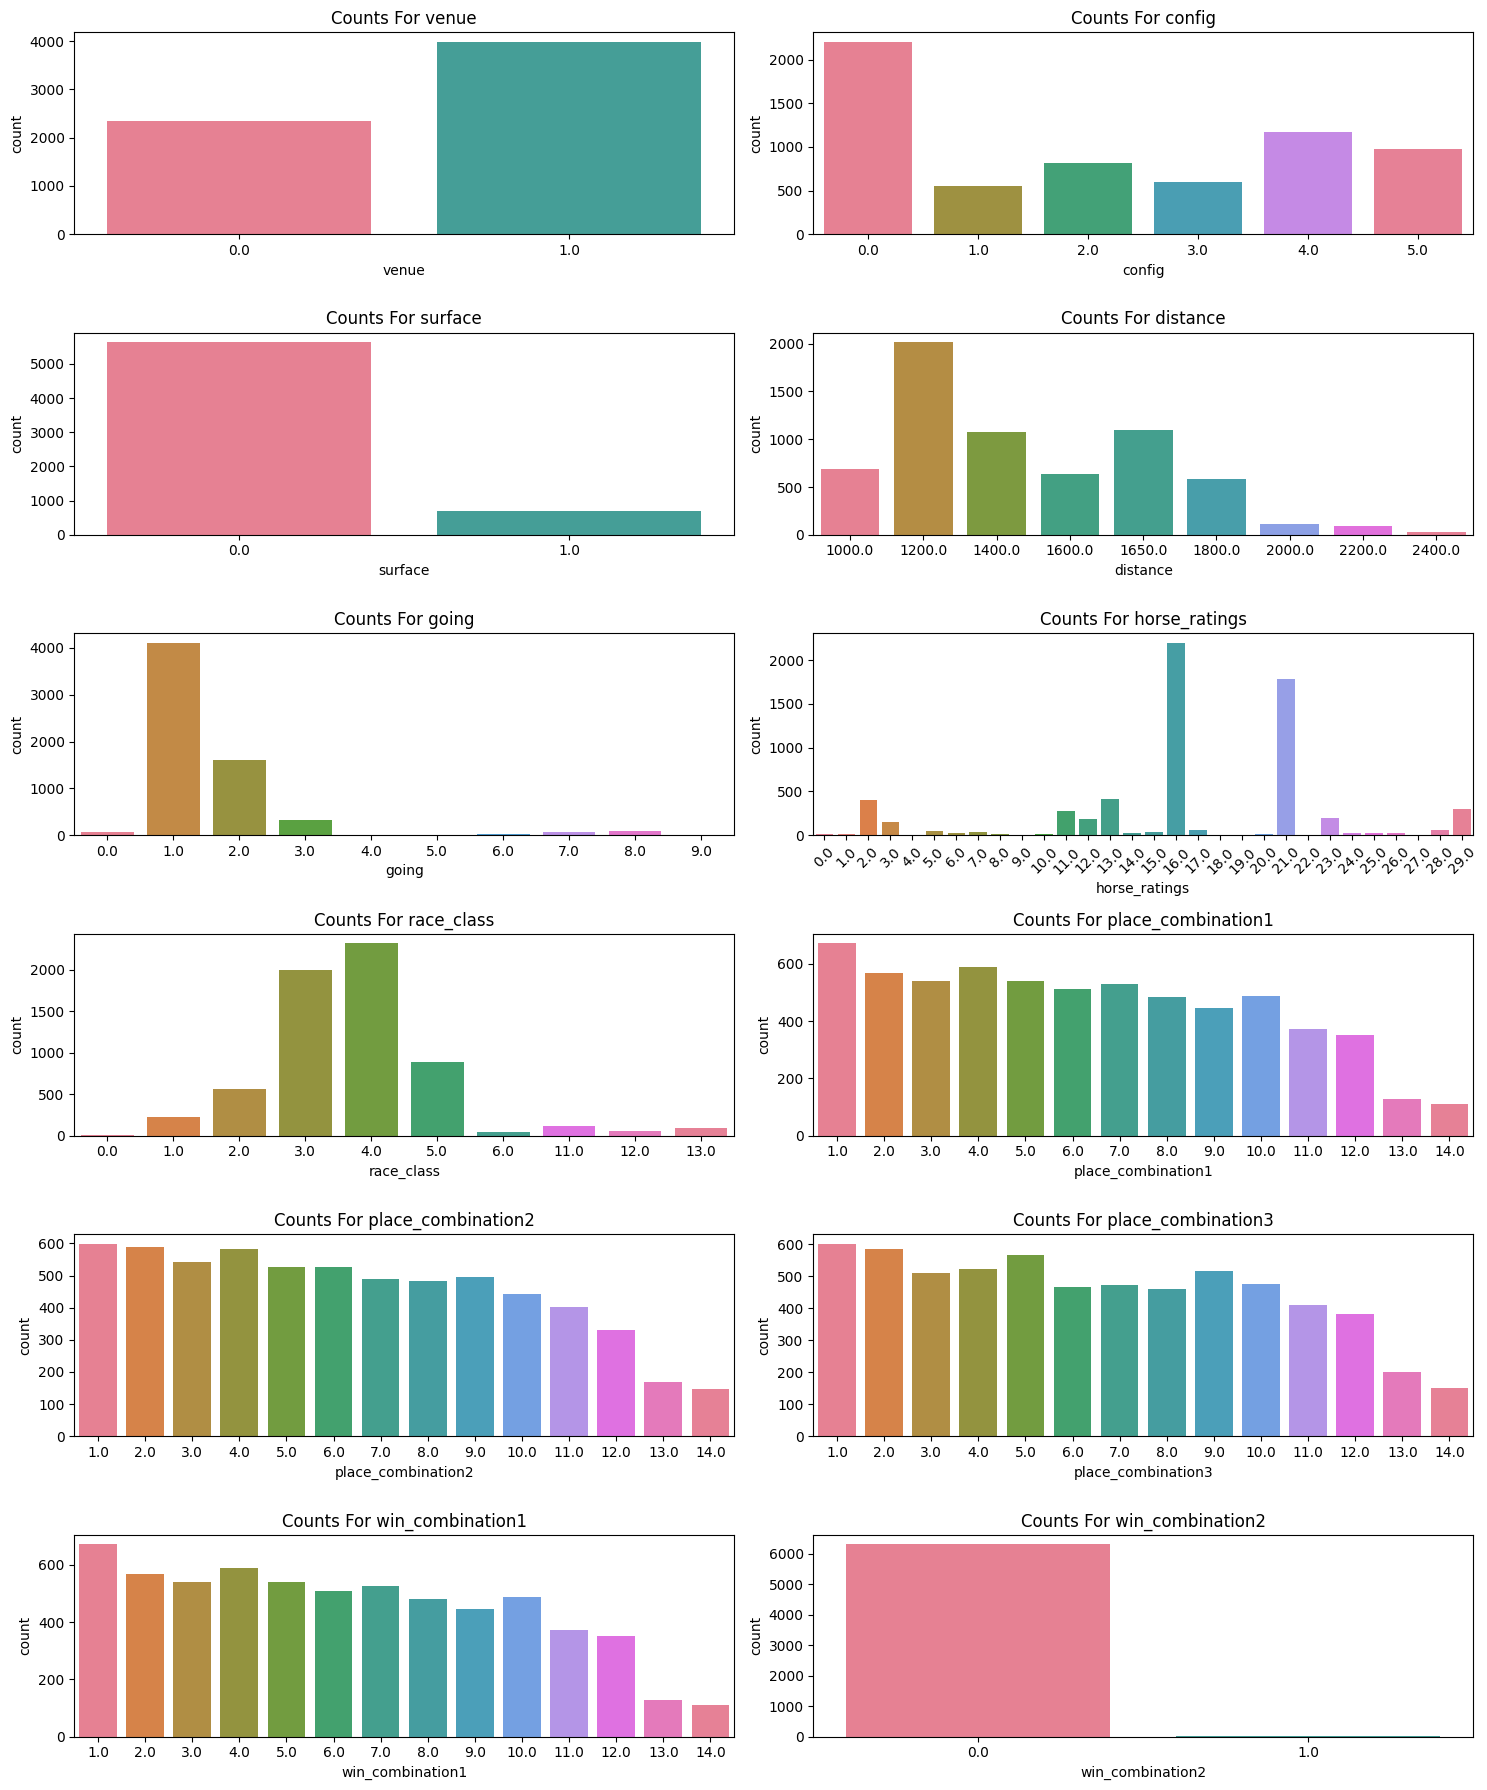

In [ ]:
i = 1
plt.figure(figsize=(15, 18))

for col in cat_races_df.columns:
    plt.subplot(6, 2, i)
    sns.countplot(x=col, data=cat_races_df, hue=col, order=sorted(cat_races_df[col].unique()), palette='husl', legend=False)
    if i == 6:
        plt.xticks(rotation=45)
    i += 1
    plt.title('Counts For ' + col)

plt.tight_layout()
plt.show()

## Factors That Affect Horse Performance

In this section, we will try to analyze which horses have a higher likelihood of winning based on past performance. We will try to gain patterns, trends, and factors that might affect's a horse's performance.

In [ ]:
winning_horses = runs_dropped_cleaned_df[runs_dropped_cleaned_df['won'] == 1].groupby('horse_id').size().sort_values(ascending=False)

correlation_factors = ['horse_age', 'horse_rating', 'declared_weight', 'actual_weight',
                   'draw', 'horse_country', 'horse_type', 'horse_gear']
correlation_results = runs_dropped_cleaned_df[correlation_factors + ['won']].corr()['won']

print("Winning Horses based on Past Performance:")
print(winning_horses.head(10))  # Display top 10 winning horses
print("\nFinishing Positions of Horses:")
print("\nCorrelation with Race Outcomes:")
print(correlation_results)


Winning Horses based on Past Performance:
horse_id
1960    13
1033    12
1067    11
2523    10
493     10
2558    10
2217     9
70       9
3044     9
1594     9
dtype: int64

Finishing Positions of Horses:

Correlation with Race Outcomes:
horse_age         -0.003357
horse_rating       0.014125
declared_weight    0.028733
actual_weight      0.050655
draw              -0.050192
won                1.000000
Name: won, dtype: float64


<ipython-input-225-428f1d134975>:5: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



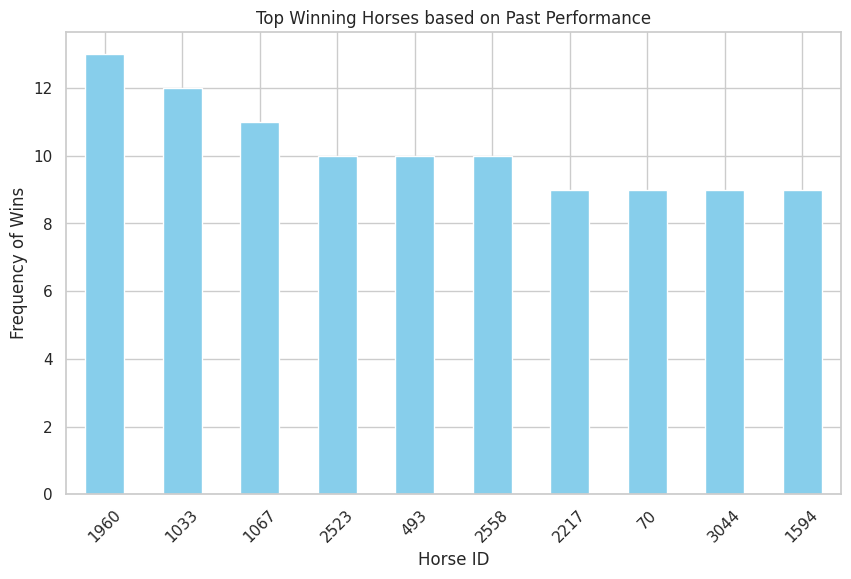

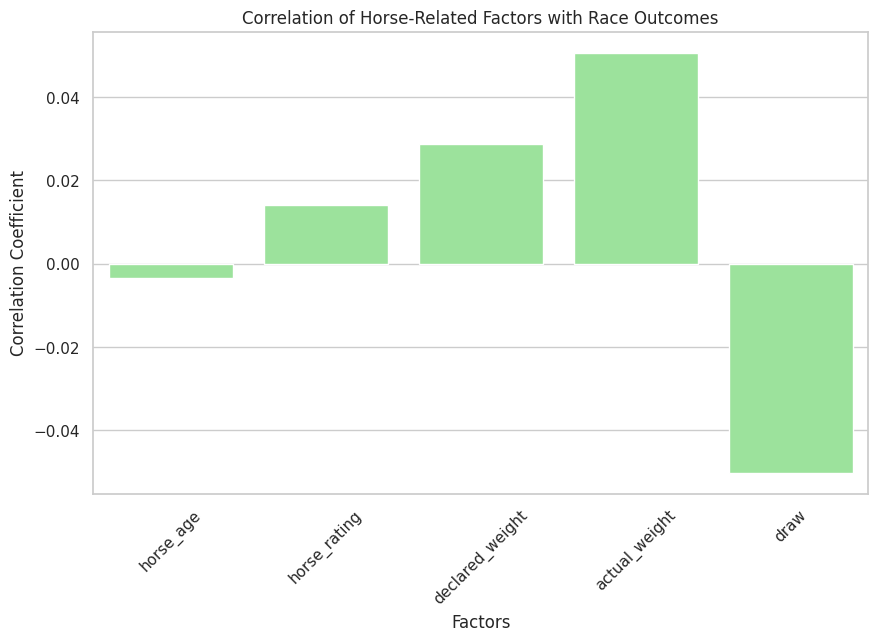

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
winning_horses.head(10).plot(kind='bar', color='skyblue')
plt.title('Top Winning Horses based on Past Performance')
plt.xlabel('Horse ID')
plt.ylabel('Frequency of Wins')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
horse_factors_correlation = correlation_results.drop('won')

sns.barplot(x=horse_factors_correlation.index, y=horse_factors_correlation.values, color='lightgreen')

plt.title('Correlation of Horse-Related Factors with Race Outcomes')
plt.xlabel('Factors')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.show()



In [ ]:
track_info_columns = ['race_id', 'venue', 'surface', 'going']
performance_columns = ['race_id','horse_id', 'result', 'won', 'lengths_behind','declared_weight','actual_weight', 'horse_country','horse_type']

# Combine relevant columns into a new dataframe
combined_df = imputed_df[track_info_columns].merge(runs_dropped_cleaned_df[performance_columns], on='race_id')
win_counts = combined_df.groupby('horse_id')['won'].sum()
race_counts = combined_df.groupby('horse_id').size()
win_percentage = (win_counts / race_counts) * 100

combined_df['win_percentage'] = combined_df['horse_id'].map(win_percentage)

<ipython-input-189-5df0ecaa5d45>:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




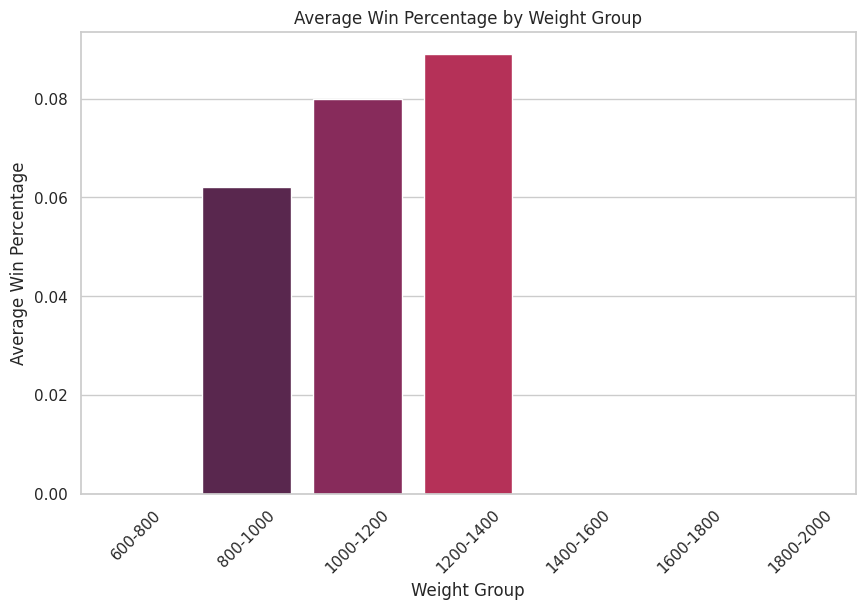

In [ ]:
import numpy as np

weight_bins = [600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
weight_labels = ['600-800', '800-1000', '1000-1200', '1200-1400', '1400-1600', '1600-1800', '1800-2000']

combined_df['weight_group'] = pd.cut(combined_df['declared_weight'], bins=weight_bins, labels=weight_labels)

weight_win_percentage = combined_df.groupby('weight_group')['won'].mean().reset_index()
weight_win_percentage.columns = ['weight_group', 'average_win_percentage']

plt.figure(figsize=(10, 6))
sns.barplot(x='weight_group', y='average_win_percentage', data=weight_win_percentage, palette = 'rocket')
plt.title('Average Win Percentage by Weight Group')
plt.xlabel('Weight Group')
plt.ylabel('Average Win Percentage')
plt.xticks(rotation=45)
plt.show()


<ipython-input-187-c212f23a81bc>:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




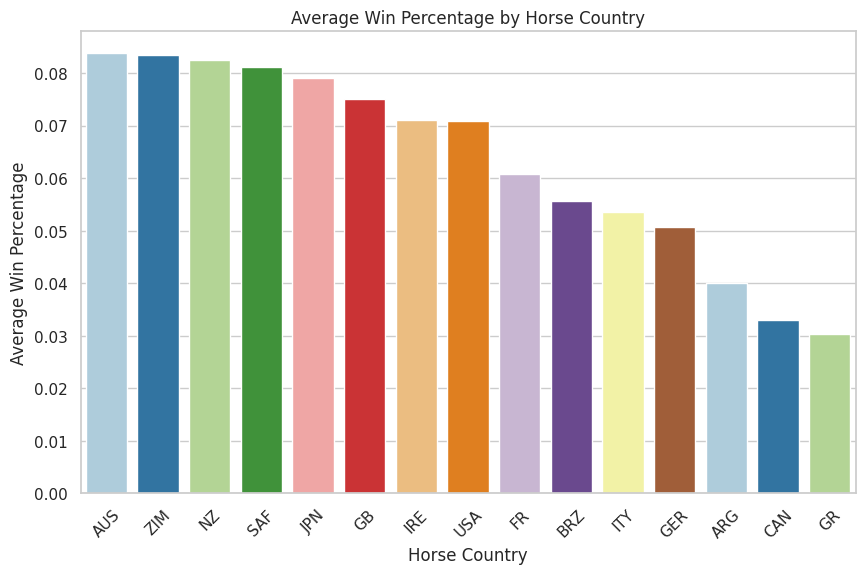

In [ ]:
country_win_percentage = combined_df.groupby('horse_country')['won'].mean().reset_index()
country_win_percentage.columns = ['horse_country', 'average_win_percentage']

country_win_percentage = country_win_percentage.sort_values(by='average_win_percentage', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='horse_country', y='average_win_percentage', data=country_win_percentage, palette='Paired')
plt.title('Average Win Percentage by Horse Country')
plt.xlabel('Horse Country')
plt.ylabel('Average Win Percentage')
plt.xticks(rotation=45)
plt.show()


<ipython-input-188-ff0ef6cf2c3e>:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




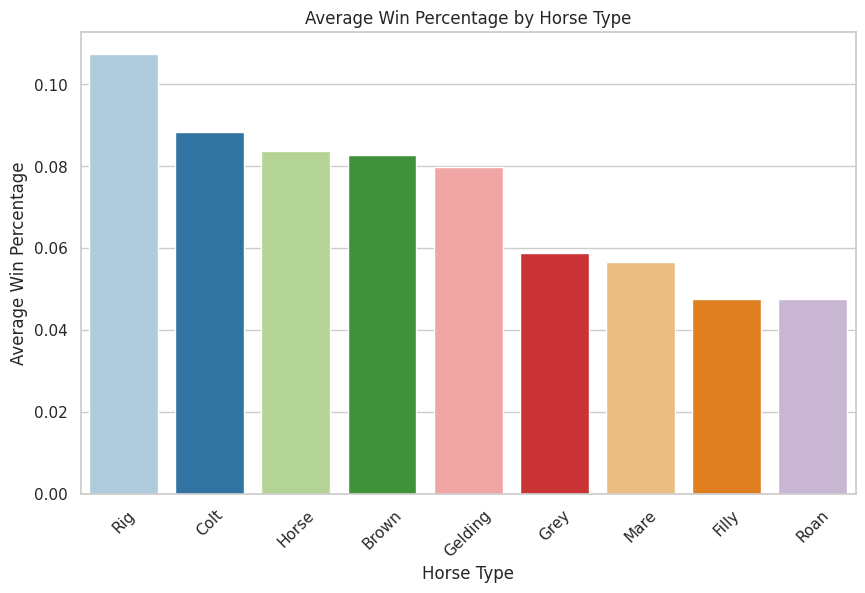

In [ ]:
type_win_percentage = combined_df.groupby('horse_type')['won'].mean().reset_index()
type_win_percentage.columns = ['horse_type', 'average_win_percentage']

type_win_percentage = type_win_percentage.sort_values(by='average_win_percentage', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='horse_type', y='average_win_percentage', data=type_win_percentage, palette = 'Paired')
plt.title('Average Win Percentage by Horse Type')
plt.xlabel('Horse Type')
plt.ylabel('Average Win Percentage')
plt.xticks(rotation=45)
plt.show()


## Track Conditions

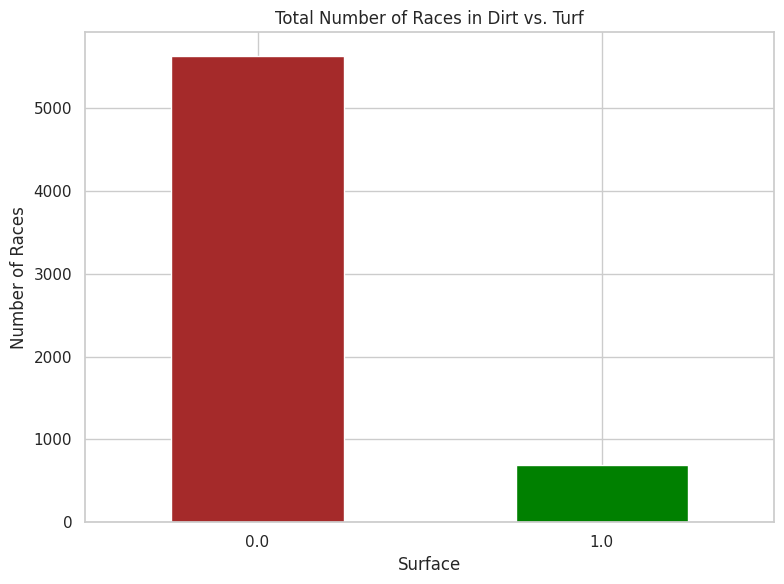

In [ ]:
surface_counts = imputed_df['surface'].value_counts()

plt.figure(figsize=(8, 6))
surface_counts.plot(kind='bar', color=['brown', 'green'])
plt.title('Total Number of Races in Dirt vs. Turf')
plt.xlabel('Surface')
plt.ylabel('Number of Races')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
track_info_columns = ['race_id', 'venue', 'surface', 'going']
performance_columns = ['race_id','horse_id', 'result', 'won', 'lengths_behind']  # Adjust as per your dataset

combined_df = imputed_df[track_info_columns].merge(runs_dropped_cleaned_df[performance_columns], on='race_id')

In [ ]:
dirt_wins = combined_df[combined_df['surface'] == 1].groupby('horse_id')['won'].sum().reset_index()
dirt_wins.columns = ['horse_id', 'dirt_wins']

In [ ]:
turf_wins = combined_df[combined_df['surface'] == 0].groupby('horse_id')['won'].sum().reset_index()
turf_wins.columns = ['horse_id', 'turf_wins']

In [ ]:
combined_wins_df = pd.merge(dirt_wins, turf_wins, on='horse_id', how='outer')
combined_wins_df.fillna(0, inplace=True)

In [ ]:
total_races_dirt = combined_df[combined_df['surface'] == 1].groupby('horse_id').size().reset_index()
total_races_dirt.columns = ['horse_id', 'dirt_races_played']

In [ ]:
total_races_turf = combined_df[combined_df['surface'] == 0].groupby('horse_id').size().reset_index()
total_races_turf.columns = ['horse_id', 'turf_races_played']

In [ ]:
combined_wins_df = pd.merge(combined_wins_df, total_races_dirt, on='horse_id', how='outer')
combined_wins_df = pd.merge(combined_wins_df, total_races_turf, on='horse_id', how='outer')

In [ ]:
combined_wins_df['win_percentage_dirt'] = combined_wins_df['dirt_wins'] / combined_wins_df['dirt_races_played']

combined_wins_df['win_percentage_turf'] = combined_wins_df['turf_wins'] / combined_wins_df['turf_races_played']

dirt_horses = combined_wins_df[(combined_wins_df['dirt_races_played']) >= 15]
turf_horses = combined_wins_df[(combined_wins_df['turf_races_played']) >= 15]

top_10_dirt_horses = dirt_horses.sort_values(by='win_percentage_dirt', ascending=False).head(10)

top_10_turf_horses = turf_horses.sort_values(by='win_percentage_turf', ascending=False).head(10)

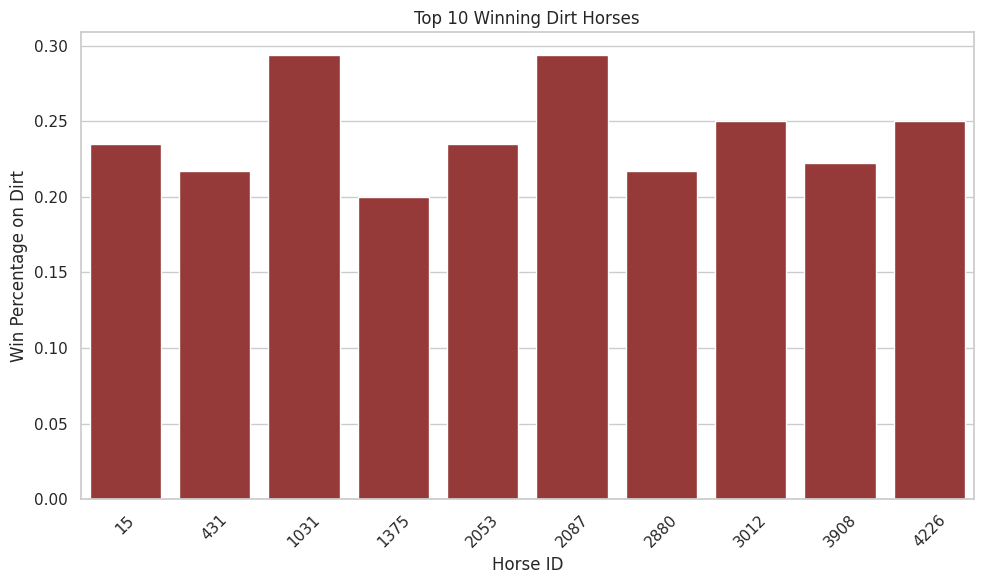

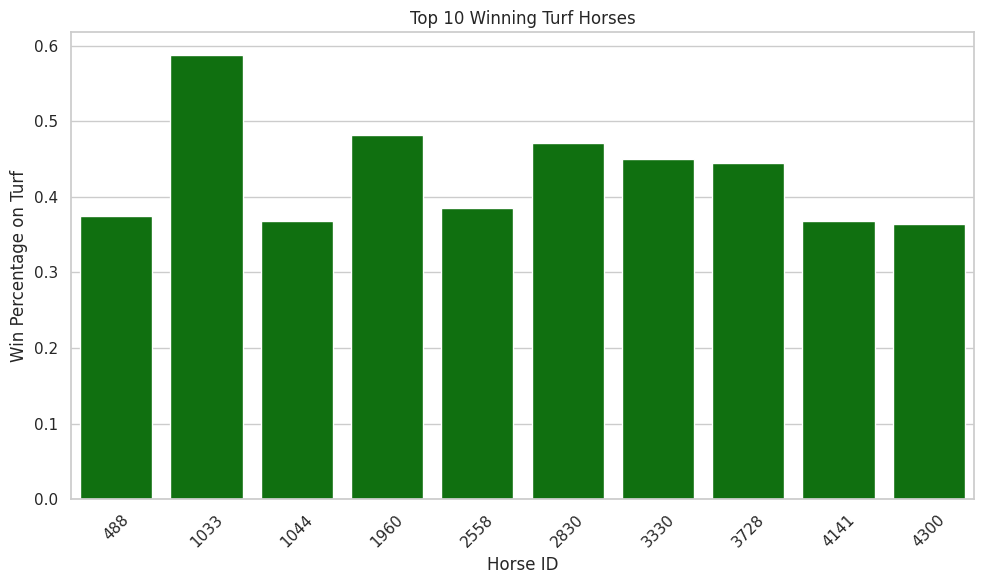

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_dirt_horses['horse_id'], y=top_10_dirt_horses['win_percentage_dirt'], color='brown')
plt.title('Top 10 Winning Dirt Horses')
plt.xlabel('Horse ID')
plt.ylabel('Win Percentage on Dirt')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x = top_10_turf_horses['horse_id'], y = top_10_turf_horses['win_percentage_turf'], color='green')
plt.title('Top 10 Winning Turf Horses')
plt.xlabel('Horse ID')
plt.ylabel('Win Percentage on Turf')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Jockey and Trainer Analysis

One another factors that is interesting to look at is whether the way the horse is trained and the way the horse is ridden has an impact on wins. In this section, we will explore how the win percetages of top jockeys and trainers.

In [ ]:
track_info_columns = ['race_id', 'venue', 'surface', 'going']
performance_columns = ['race_id','horse_id', 'result', 'won', 'lengths_behind','declared_weight','actual_weight', 'horse_country','horse_type','jockey_id','trainer_id']

combined_df = imputed_df[track_info_columns].merge(runs_dropped_cleaned_df[performance_columns], on='race_id')
win_counts = combined_df.groupby('horse_id')['won'].sum()
race_counts = combined_df.groupby('horse_id').size()
win_percentage = (win_counts / race_counts) * 100

combined_df['win_percentage'] = combined_df['horse_id'].map(win_percentage)

In [ ]:
jockey_total_races = combined_df.groupby('jockey_id').size().reset_index()
jockey_total_races.columns = ['jockey_id', 'total_races']


In [ ]:
trainer_total_races = combined_df.groupby('trainer_id').size().reset_index()
trainer_total_races.columns = ['trainer_id', 'total_races']

In [ ]:
jockey_win_percentage = combined_df.groupby('jockey_id')['won'].mean().reset_index()
jockey_win_percentage.columns = ['jockey_id', 'win_percentage']
jockey_win_percentage = pd.merge(jockey_win_percentage, jockey_total_races, on='jockey_id', how='left')

In [ ]:
trainer_win_percentage = combined_df.groupby('trainer_id')['won'].mean().reset_index()
trainer_win_percentage.columns = ['trainer_id', 'win_percentage']
trainer_win_percentage = pd.merge(trainer_win_percentage, trainer_total_races, on='trainer_id', how='left')

jockey_win_percentage_filtered = jockey_win_percentage[jockey_win_percentage['total_races'] >= 15]
trainer_win_percentage_filtered = trainer_win_percentage[trainer_win_percentage['total_races'] >= 15]

In [ ]:
top_jockeys = jockey_win_percentage_filtered.nlargest(10, 'win_percentage')
top_trainers = trainer_win_percentage_filtered.nlargest(10, 'win_percentage')

<ipython-input-222-abbd19fdef08>:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




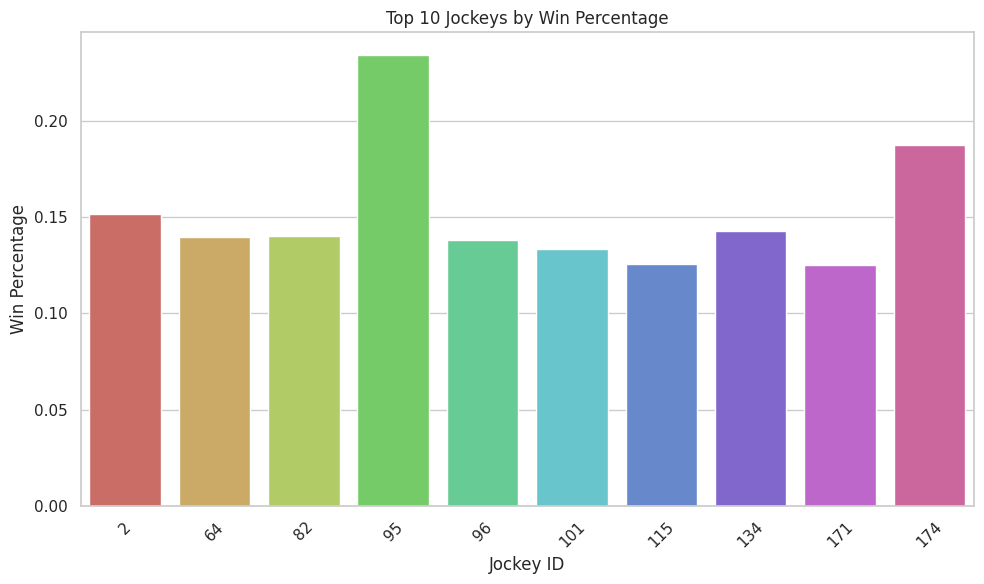

In [ ]:
top_jockeys = jockey_win_percentage_filtered.nlargest(10, 'win_percentage')

plt.figure(figsize=(10, 6))
sns.barplot(x = top_jockeys['jockey_id'], y = top_jockeys['win_percentage'], palette='hls')
plt.title('Top 10 Jockeys by Win Percentage')
plt.xlabel('Jockey ID')
plt.ylabel('Win Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<ipython-input-223-a2d45c916451>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




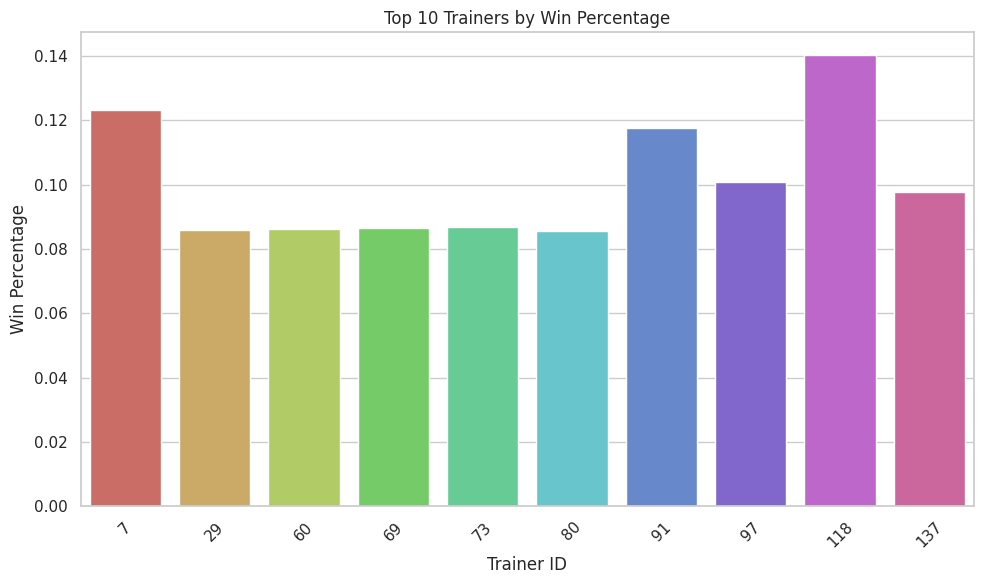

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x = top_trainers['trainer_id'], y = top_trainers['win_percentage'], palette='hls')
plt.title('Top 10 Trainers by Win Percentage')
plt.xlabel('Trainer ID')
plt.ylabel('Win Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Feature Engineering

In the Data Pre-Processing Section, ```runs_df``` did not have its categorical columns encoded. We will begin our feature engineering process by label encoding ```runs_df``` using Label Encoder

In [ ]:
cat_columns = ['horse_country','horse_type','horse_gear']
label_encoder = LabelEncoder()

for column in cat_columns:
    runs_dropped_cleaned_df[column] = label_encoder.fit_transform(runs_dropped_cleaned_df[column])

In [ ]:
runs_dropped_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 75710 entries, 0 to 76710
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   race_id          75710 non-null  int64  
 1   horse_no         75710 non-null  int64  
 2   horse_id         75710 non-null  int64  
 3   result           75710 non-null  int64  
 4   won              75710 non-null  float64
 5   lengths_behind   75710 non-null  float64
 6   horse_age        75710 non-null  int64  
 7   horse_country    75710 non-null  int64  
 8   horse_type       75710 non-null  int64  
 9   horse_rating     75710 non-null  int64  
 10  horse_gear       75710 non-null  int64  
 11  declared_weight  75710 non-null  float64
 12  actual_weight    75710 non-null  int64  
 13  draw             75710 non-null  int64  
 14  position_sec1    75710 non-null  int64  
 15  position_sec2    75710 non-null  int64  
 16  position_sec3    75710 non-null  int64  
 17  behind_sec1 

First, we will combine both dataframes into one to ensure we use features from both of them.

In [ ]:
merged_df = imputed_df.merge(runs_dropped_cleaned_df, on='race_id', how='inner', suffixes=('race', 'run'))

In [ ]:
merged_df.columns

Index(['race_id', 'venue', 'race_no', 'config', 'surface', 'distance', 'going',
       'horse_ratings', 'prize', 'race_class', 'sec_time1', 'sec_time2',
       'sec_time3', 'sec_time4', 'sec_time5', 'sec_time6', 'time1race',
       'time2race', 'time3race', 'time4', 'time5', 'time6',
       'place_combination1', 'place_combination2', 'place_combination3',
       'place_dividend1', 'place_dividend2', 'place_dividend3',
       'win_combination1', 'win_dividend1', 'win_combination2',
       'win_dividend2', 'year', 'month', 'day', 'horse_no', 'horse_id',
       'result', 'won', 'lengths_behind', 'horse_age', 'horse_country',
       'horse_type', 'horse_rating', 'horse_gear', 'declared_weight',
       'actual_weight', 'draw', 'position_sec1', 'position_sec2',
       'position_sec3', 'behind_sec1', 'behind_sec2', 'behind_sec3',
       'time1run', 'time2run', 'time3run', 'finish_time', 'win_odds',
       'place_odds', 'trainer_id', 'jockey_id'],
      dtype='object')

In [ ]:
num_columns =        ['race_no', 'surface', 'distance', 'prize', 'race_class',
                     'sec_time1', 'sec_time2', 'sec_time3', 'sec_time4', 'sec_time5', 'sec_time6',
                     'time1race', 'time2race', 'time3race', 'time4', 'time5', 'time6',
                     'place_combination1', 'place_combination2', 'place_combination3',
                     'place_dividend1', 'place_dividend2', 'place_dividend3',
                     'win_combination1', 'win_dividend1', 'win_combination2', 'win_dividend2',
                     'year', 'month', 'day',
                     'horse_no', 'result', 'won', 'lengths_behind', 'horse_age', 'horse_rating',
                     'declared_weight', 'actual_weight', 'draw',
                     'position_sec1', 'position_sec2', 'position_sec3',
                     'behind_sec1', 'behind_sec2', 'behind_sec3',
                     'time1run', 'time2run', 'time3run', 'finish_time',
                     'win_odds', 'place_odds', 'trainer_id', 'jockey_id']

categorical_columns = ['venue', 'config', 'going', 'horse_ratings', 'horse_country', 'horse_type', 'horse_gear']

<Axes: >

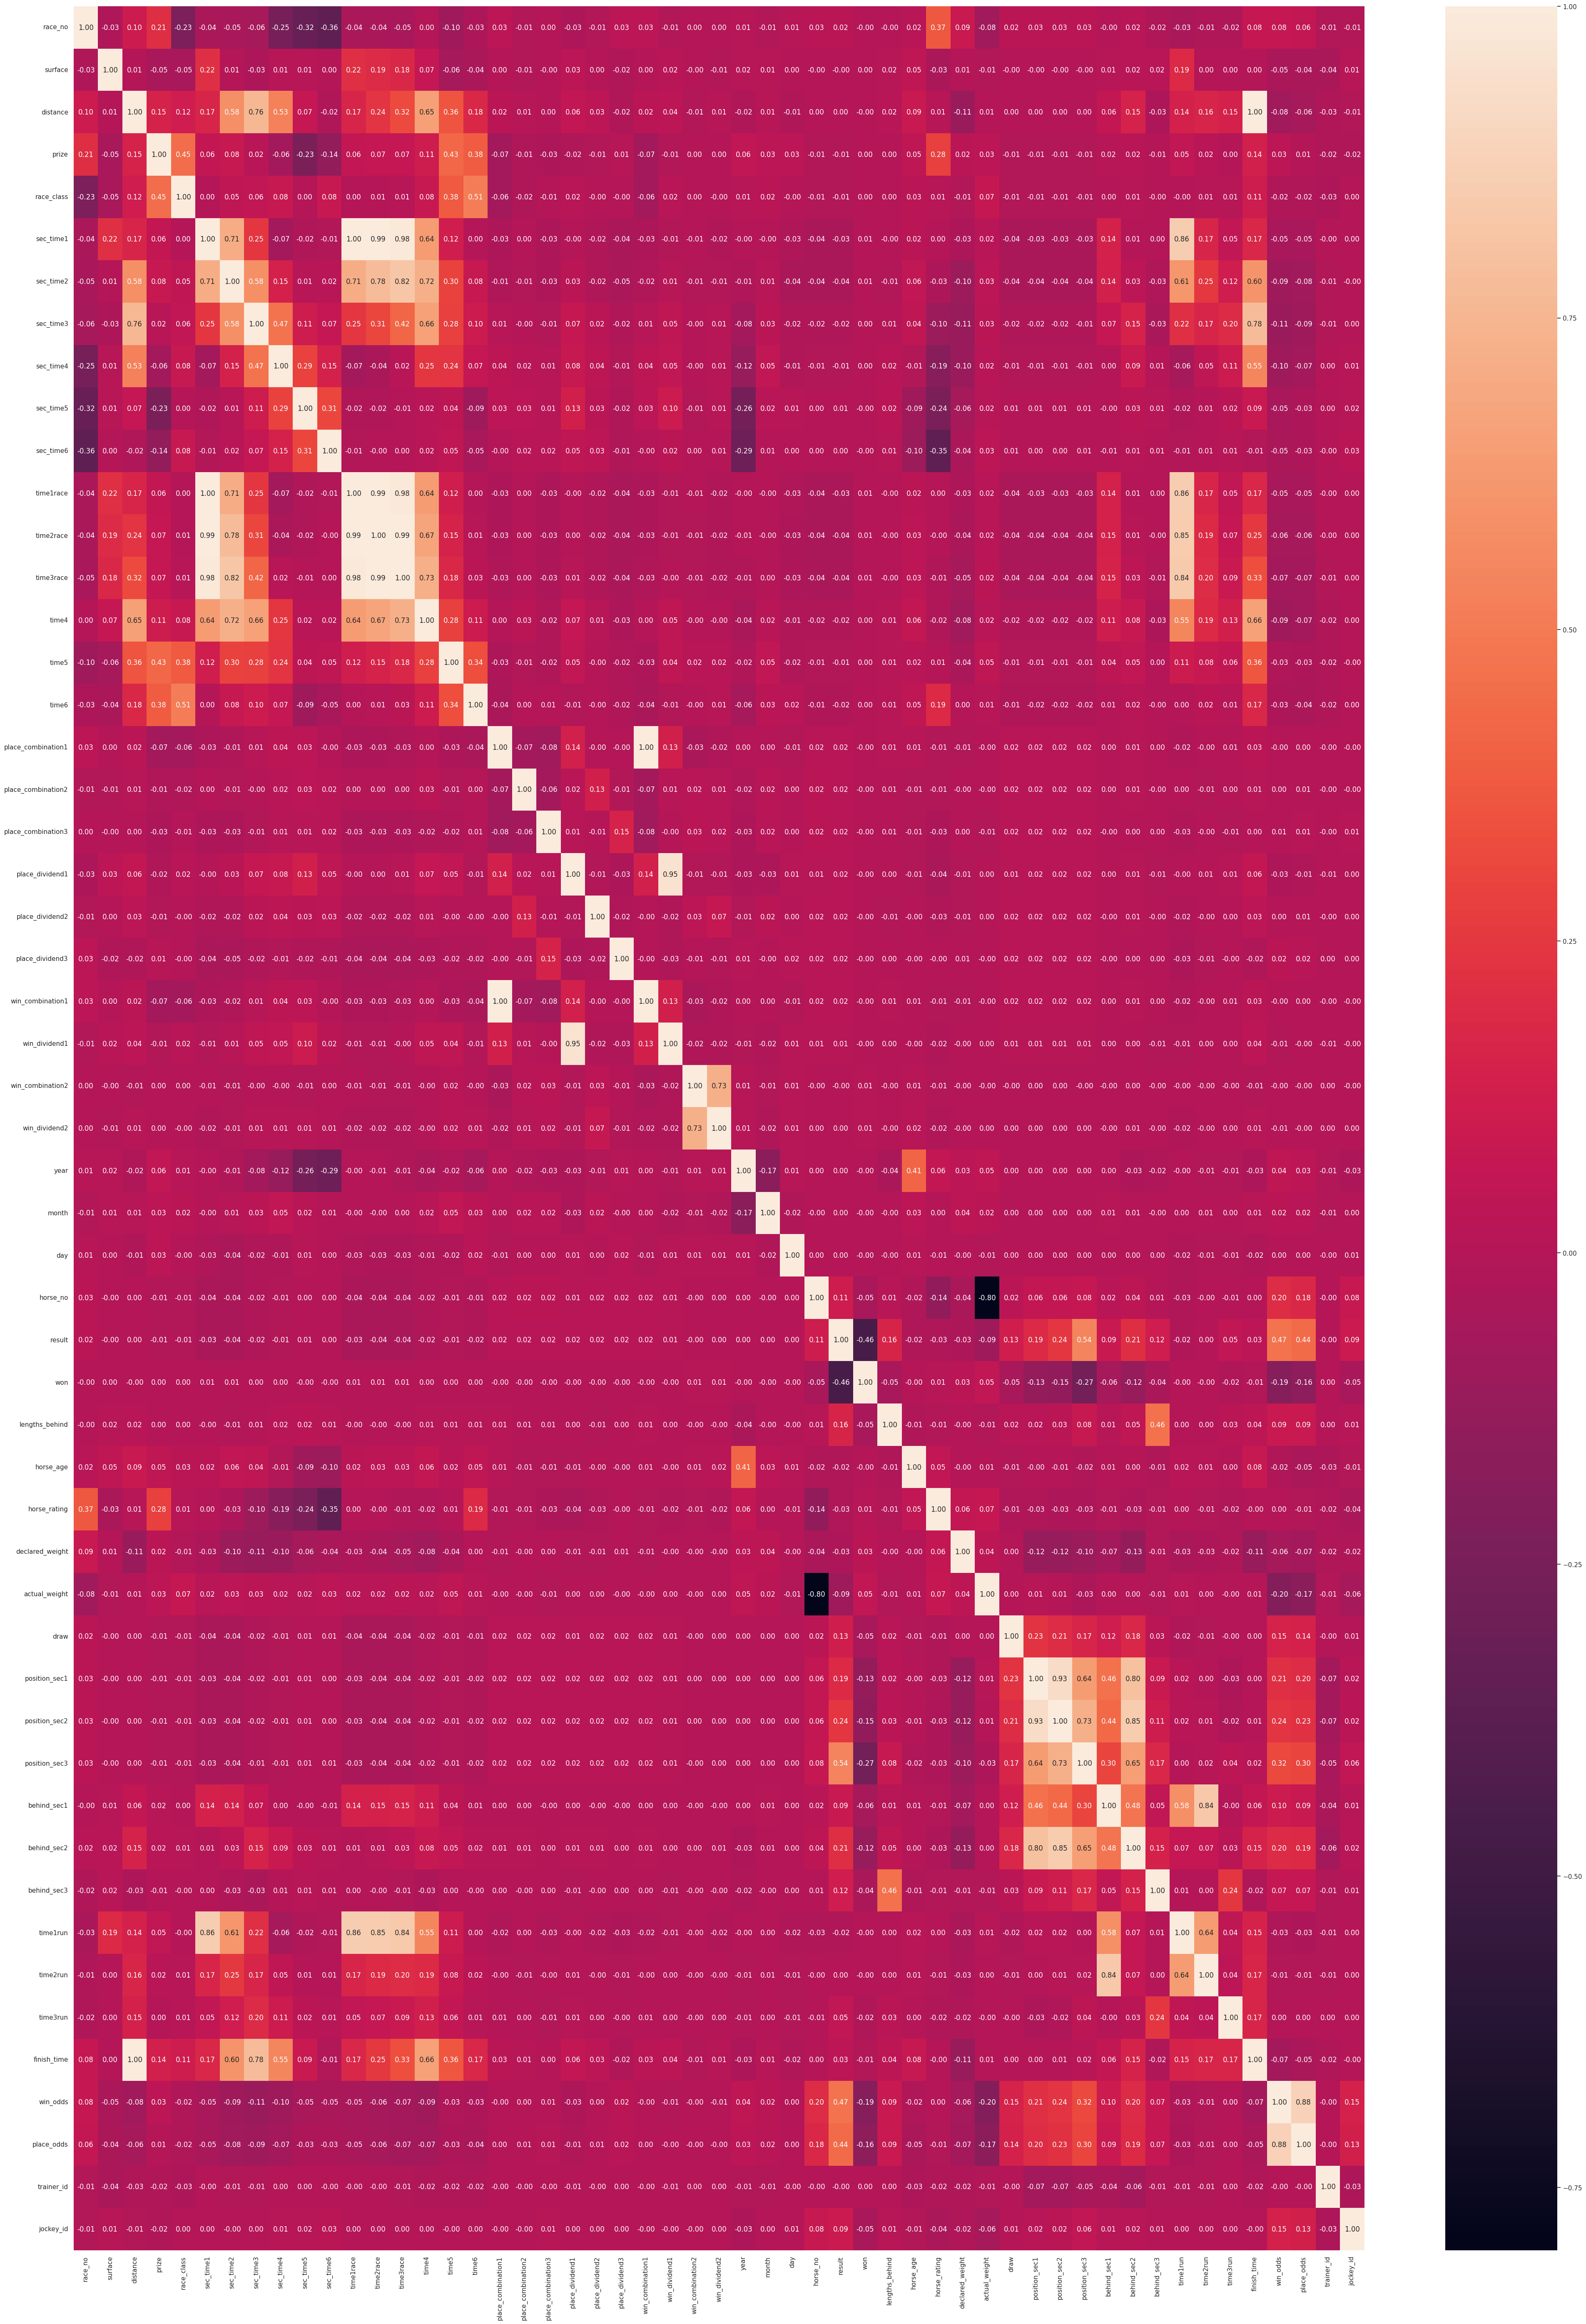

In [ ]:
plt.figure(figsize=(50, 70))
corr_mat = merged_df[num_columns].corr()
sns.heatmap(corr_mat, annot=True, cmap='rocket', fmt=".2f")

We will now scale our data. Scaling is neccesarry for various Machine learning algorithms. We will also spliti our data into train, and test data. We will split the data into 80% training and 20% testing. Our target variable will be ```finish_time```.

In [ ]:
num_data = merged_df[num_columns]
num_data.drop('finish_time', axis=1, inplace=True)  # Drop 'finish_time' column from num_data
cat_data = merged_df[categorical_columns]

X = pd.concat([num_data, cat_data], axis=1)
y = merged_df['finish_time']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_data.columns])  # Scale training data
X_test_num = scaler.transform(X_test[num_data.columns])  # Scale test data

X_train_num = pd.DataFrame(X_train_num, columns=num_data.columns, index=X_train.index)
X_test_num = pd.DataFrame(X_test_num, columns=num_data.columns, index=X_test.index)

x_train_sc = pd.concat([X_train_num, pd.get_dummies(X_train[cat_data.columns])], axis=1)
x_test_sc = pd.concat([X_test_num, pd.get_dummies(X_test[cat_data.columns])], axis=1)

# Initial Modeling

## PCA Model

We will first begin modeling by using PCA model to create features. This will reduce dimensionality and decrease the colinearty that existed in our original dataset.

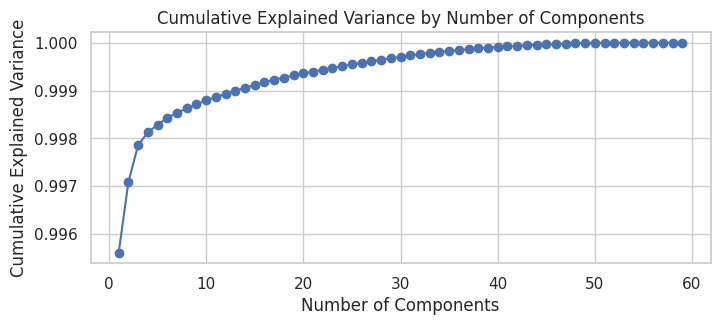

In [ ]:

pca = PCA()
pca.fit(x_train_sc)

explained_variance_ratios = pca.explained_variance_ratio_

cum_evr = explained_variance_ratios.cumsum()

cumulative_explained_variance = []

for n in range(1, len(explained_variance_ratios) + 1):
    pca = PCA(n_components=n)
    pca.fit(x_train_sc)
    cumulative_explained_variance.append(sum(pca.explained_variance_ratio_))

# Plotting the cumulative explained variance against the number of components
plt.figure(figsize=(8, 3))
plt.plot(range(1, len(explained_variance_ratios) + 1), cumulative_explained_variance, marker='o')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [ ]:
import plotly.graph_objects as go

In [ ]:
# Extract the PCA components
loadings = pca.components_

# Create a DataFrame of loadings with variables as columns
loadings_df = pd.DataFrame(loadings, columns=x_train_sc.columns, index=[f'PC{i+1}' for i in range(len(loadings))])
# Select the first few principal components for visualization
loadings_selected = loadings_df.iloc[:5, :]

# Create the heatmap
fig = go.Figure(data=go.Heatmap(
    z=loadings_selected.values,
    x=loadings_selected.columns,
    y=loadings_selected.index,
    colorscale='Viridis'
))

# Update layout
fig.update_layout(
    title='PCA Loadings',
    xaxis_title='Features',
    yaxis_title='Principal Components',
    xaxis={'side': 'bottom'},
    yaxis_autorange='reversed'  # Reverse y-axis for better comparison with sns.heatmap
)

fig.show()

In [ ]:
desired_components = 30

pca_final = PCA(n_components=desired_components)
x_train_pca = pca_final.fit_transform(x_train_sc)
x_test_pca = pca_final.transform(x_test_sc)

## Linear Regression to Predict ```finish_time```

Elastic Net Model Using Original Features

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

elastic_net_model = ElasticNet(alpha=1.0, l1_ratio=0.9)  # Adjust alpha and l1_ratio as needed
elastic_net_model.fit(x_train_sc, y_train)

y_pred_train = elastic_net_model.predict(x_train_sc)


y_pred_en = elastic_net_model.predict(x_test_sc)


mse_train = mean_squared_error(y_train, y_pred_train)
mse_en = mean_squared_error(y_test, y_pred_en)
print("Elastic Net Regression MSE on Train Data: ", mse_train)
print("Elastic Net Regression MSE on Test Data:", mse_en)

Elastic Net Regression MSE on Train Data:  7.242299951549346
Elastic Net Regression MSE on Test Data: 15.944338248845083


In [ ]:
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_en)
print("Training R^2 score:", train_r2)
print("Testing R^2 score:", test_r2)

Training R^2 score: 0.9789303527931089
Testing R^2 score: 0.9535217138049151


## Linear Regression using PCA Data

In [ ]:
elastic_net_model_pca = ElasticNet(alpha=1.0, l1_ratio=0.9)  # Adjust alpha and l1_ratio as needed
elastic_net_model_pca.fit(x_train_pca, y_train)

y_pred_train_pca = elastic_net_model_pca.predict(x_train_pca)


y_pred_en_pca = elastic_net_model_pca.predict(x_test_pca)


mse_train_pca = mean_squared_error(y_train, y_pred_train_pca)
mse_en_pca = mean_squared_error(y_test, y_pred_en_pca)
print("Elastic Net Regression MSE on Train Data: ", mse_train_pca)
print("Elastic Net Regression MSE on Test Data:", mse_en_pca)

Elastic Net Regression MSE on Train Data:  55.48310840061936
Elastic Net Regression MSE on Test Data: 896.6783149095725


In [ ]:
train_r2_pca = r2_score(y_train, y_pred_train_pca)
test_r2_pca = r2_score(y_test, y_pred_en_pca)
print("Training R^2 score:", train_r2_pca)
print("Testing R^2 score:", test_r2_pca)

Training R^2 score: 0.8385858735811323
Testing R^2 score: -1.6138476677332374


Overall, the model performs much worse when using PCA components. Hence, we will use the orignal sclaed features for our model.

# Recursive Feature Elimination

We will now try to find the 20 most predictive features that will help predict ```finish_time``` using a feature elimination method called Recursive Feature Elimination.

In [ ]:
from sklearn.feature_selection import RFE
estimator = LinearRegression()
rfe = RFE(estimator, n_features_to_select=20)  # Select 5 most important features
rfe.fit(x_train_sc, y_train)
selected_features = X_train.columns[rfe.support_]
print("Selected Features:", selected_features)


Selected Features: Index(['distance', 'sec_time1', 'sec_time2', 'sec_time3', 'sec_time4',
       'sec_time5', 'time1race', 'time4', 'place_combination1',
       'win_combination1', 'result', 'lengths_behind', 'position_sec1',
       'position_sec3', 'behind_sec1', 'behind_sec2', 'behind_sec3',
       'time1run', 'time2run', 'time3run'],
      dtype='object')


In [ ]:
X_selected = merged_df[selected_features]
y_selected = merged_df['finish_time']

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y_selected, test_size=0.2, random_state=42)


scaler2 = StandardScaler()

X_train_sc2 = scaler2.fit_transform(X_train_sel)  # Scale training data
X_test_sc2 = scaler2.transform(X_test_sel)  # Scale test data

In [ ]:
elastic_net_model = ElasticNet(alpha=1.0, l1_ratio=1.0)  # Adjust alpha and l1_ratio as needed
elastic_net_model.fit(X_train_sc2, y_train_sel)

y_pred_train = elastic_net_model.predict(X_train_sc2)


y_pred_en = elastic_net_model.predict(X_test_sc2)


mse_train = mean_squared_error(y_train_sel, y_pred_train)
mse_en = mean_squared_error(y_test_sel, y_pred_en)
print("Elastic Net Regression MSE on Train Data: ", mse_train)
print("Elastic Net Regression MSE on Test Data:", mse_en)

Elastic Net Regression MSE on Train Data:  2.3888955209197933
Elastic Net Regression MSE on Test Data: 12.008053682600648


In [ ]:
train_r2 = r2_score(y_train_sel, y_pred_train)
test_r2 = r2_score(y_test_sel, y_pred_en)
print("Training R^2 score:", train_r2)
print("Testing R^2 score:", test_r2)

Training R^2 score: 0.9930501102996798
Testing R^2 score: 0.9649961166782018


# Insights

## Feature Insights

Our analysis using Recursive Feature Elimination (RFE) revealed that the most
important features for predicting finish time for horses are:

       'distance', 'sec_time1', 'sec_time2', 'sec_time3', 'sec_time4',
       'sec_time5', 'time1race', 'time4', 'place_combination1',
       'win_combination1', 'result', 'lengths_behind', 'position_sec1',
       'position_sec3', 'behind_sec1', 'behind_sec2', 'behind_sec3',
       'time1run', 'time2run', 'time3run'

These features have the highest impact in prediciting the finish time of a horse in a given race. These features will allow us for decision-making process.

Our predictive models achieved an accuracy of 0.965, indicating that they are capable of providing reasonably accurate predictions for finish time predictions. Additionally, the Root Mean Squared Error (RMSE) of 12.00 suggests that, on average, our model's predictions have an error of approximately 12.00 seconds.

## Reccomendations

1. Consider race distance: Pay attention to the distance of the race and how horses have performed at similar distances in the past.
2. Analyze previous section and race times: Evaluate a horse's speed and consistency in different sections of the race as well as its overall race times in previous events.
3. Assess recent performance: Give weight to recent race performances as they may be more indicative of current form.
4. Factor in position and competitiveness: Look at how horses have fared in terms of their position and lengths behind in previous races to gauge their competitiveness and ability to finish strongly.
